In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import nibabel as nib
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.ticker import FuncFormatter

In [90]:
basepath = "/data/zachkaras/fmri_model_data/intermediate_results"
# basepath = "/s1/fmri_model_data/intermediate_results"

with open(f"{basepath}/all_results_old.pkl", 'rb') as f:
    records = pickle.load(f)
    
def nested_dict():
        return defaultdict(nested_dict)

In [89]:
records.columns

Index(['participant', 'task', 'model', 'ndelays', 'look_ahead', 'layer',
       'top_voxel_vals', 'participant_means', 'top_parcels'],
      dtype='str')

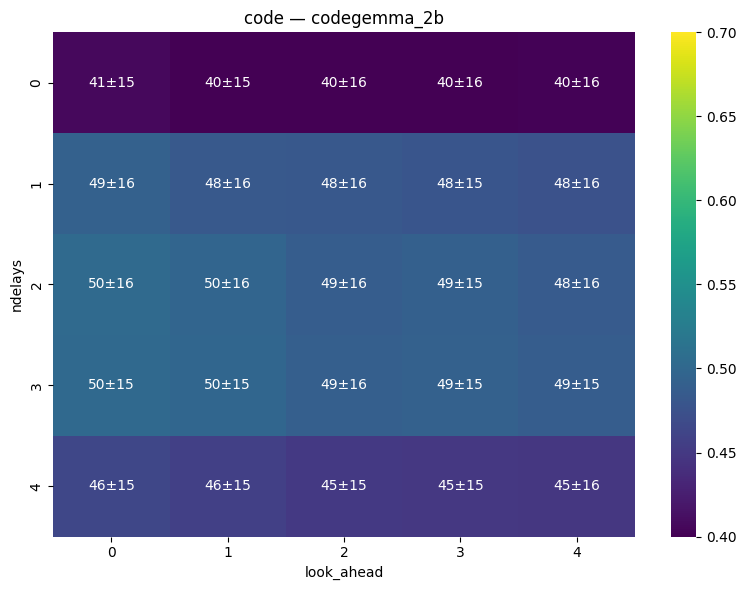

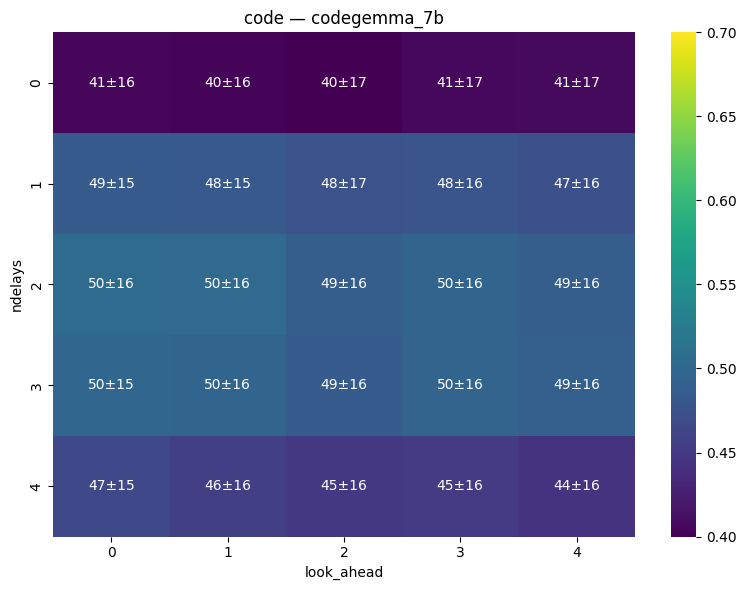

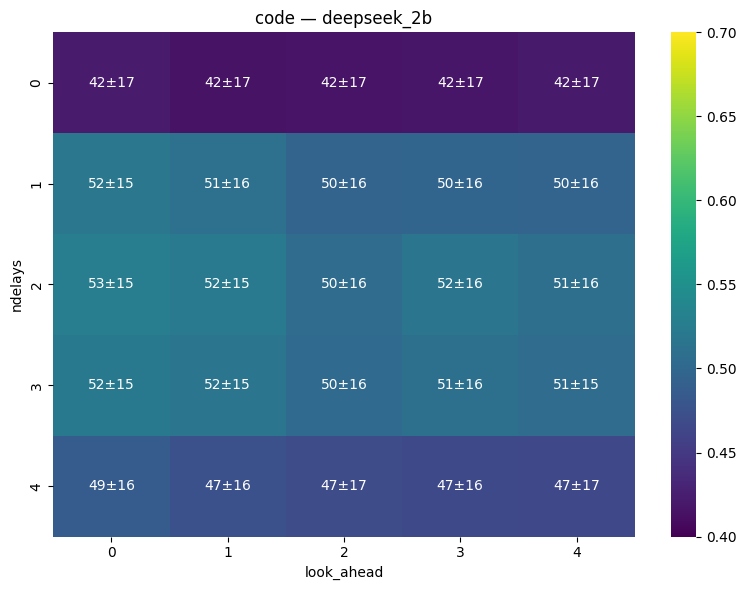

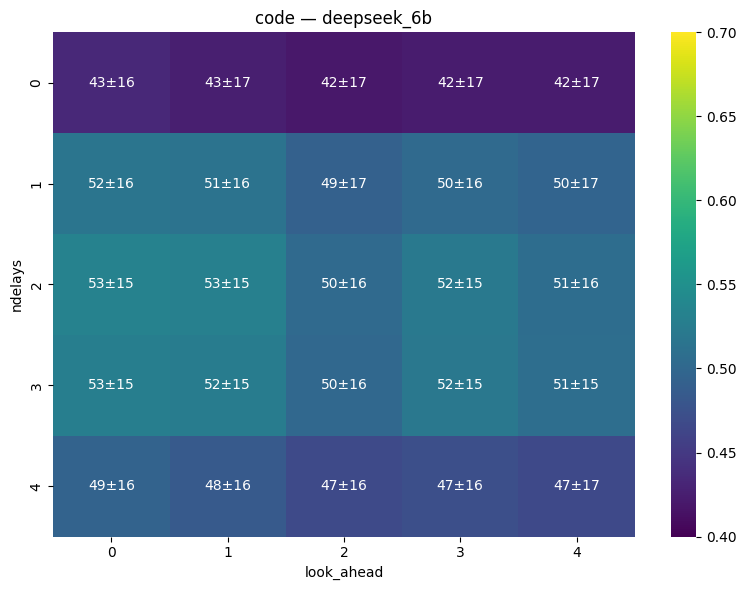

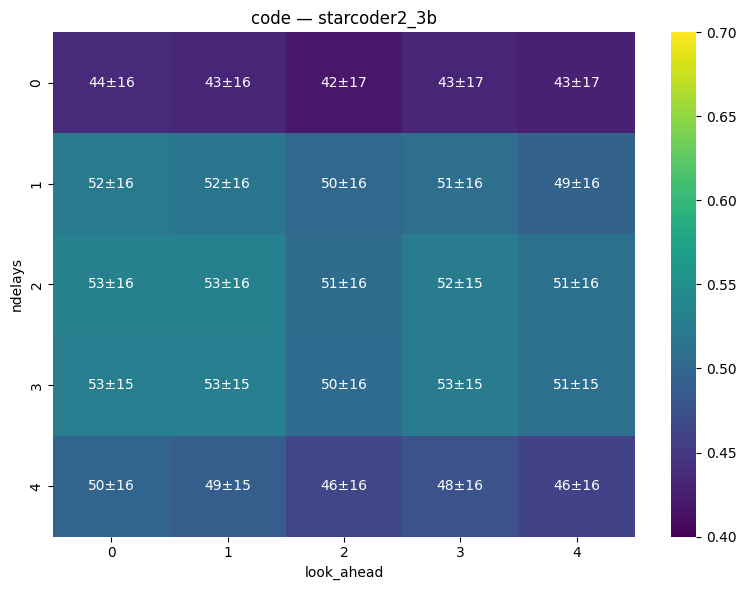

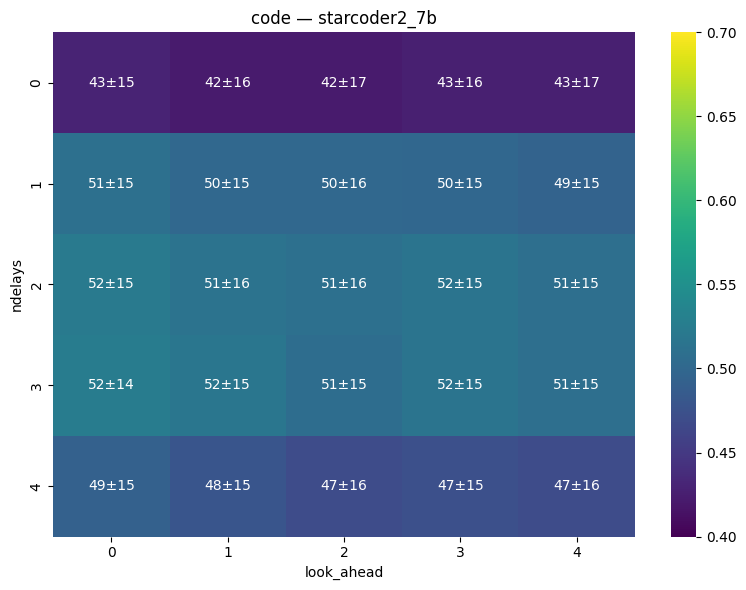

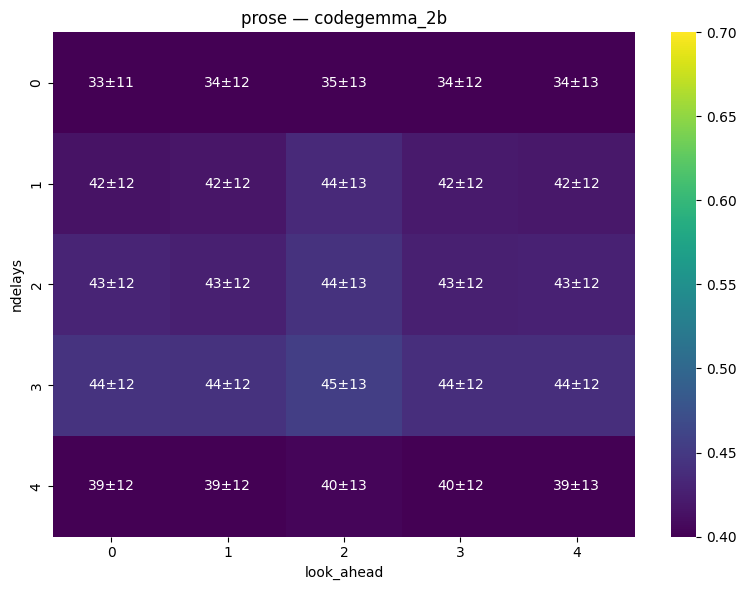

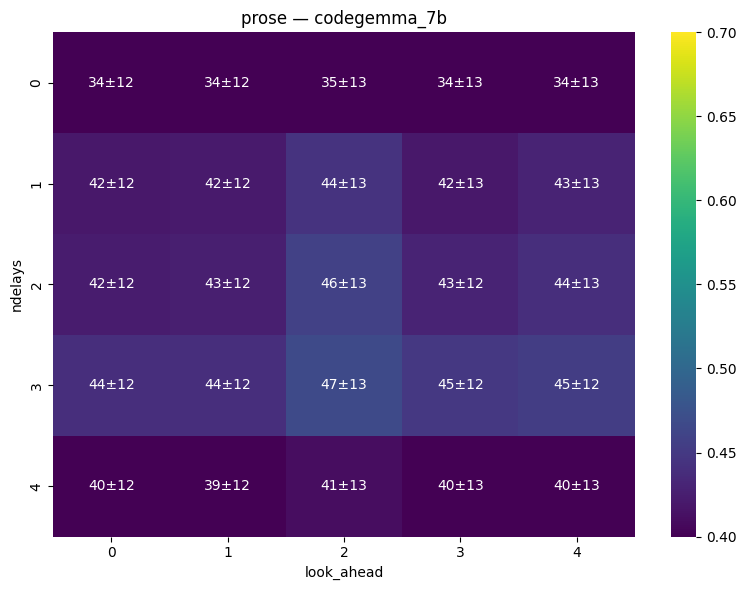

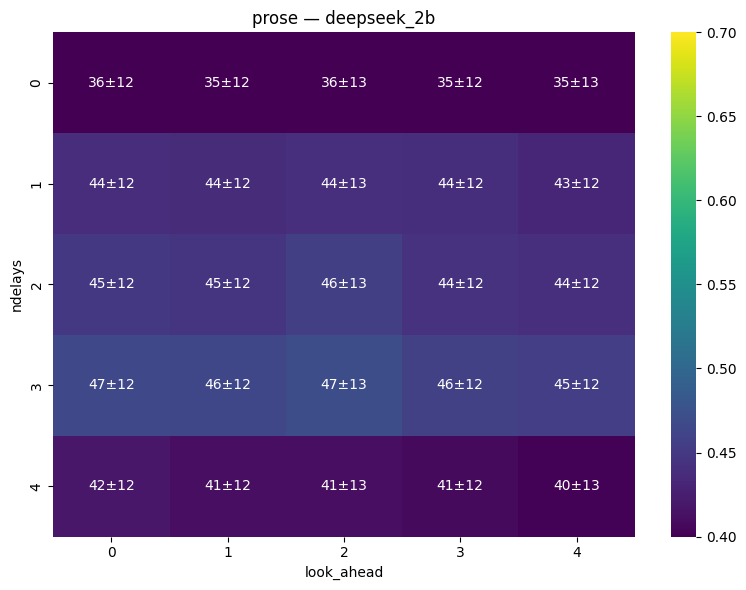

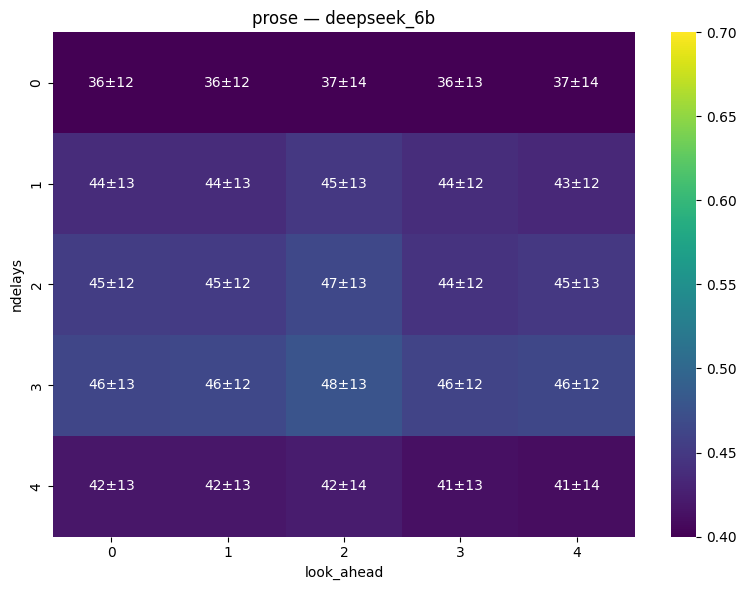

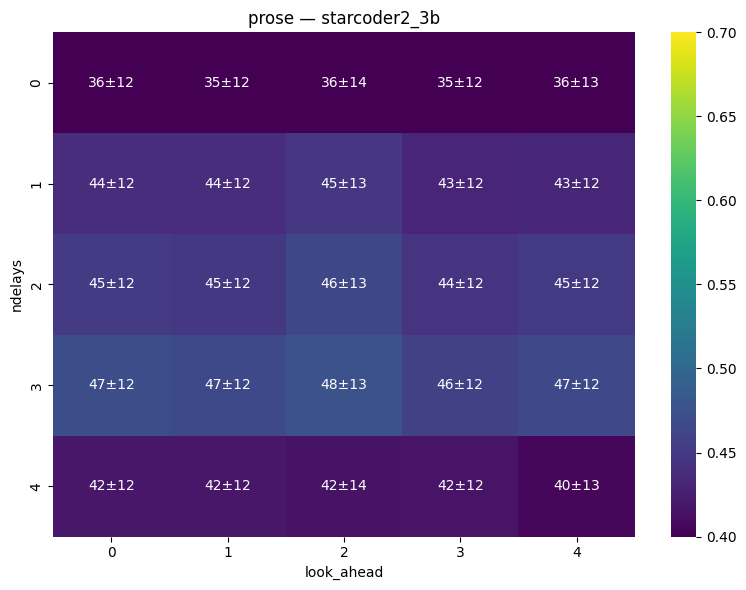

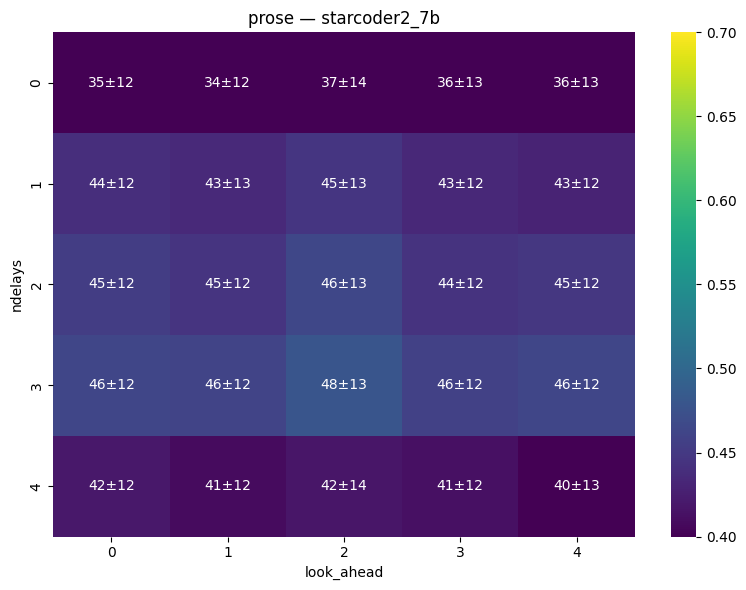

In [92]:
for (task, model), group_df in records.groupby(['task', 'model']):                                                                                                                                         
                                                                                                                                                                                                            
    # Mean participant performance across participants, grouped by the two axes                                                                                                                            
    pivot_mean = np.array(   
        group_df 
        .explode('top_voxel_vals')                                                                                                                                                                                          
        .groupby(['ndelays', 'look_ahead'])['top_voxel_vals']
        .mean()
        .unstack('look_ahead')  # look_ahead becomes columns, ndelays stays as rows
    )
    
    pivot_std = np.array(
        group_df
        .explode('top_voxel_vals')
        .groupby(['ndelays', 'look_ahead'])['top_voxel_vals']
        .std()
        .unstack('look_ahead')
    )
    
    formatted = [[f"{np.array(pivot_mean)[i][j]*100:.0f}\u00B1{np.array(pivot_std)[i][j]*100:.0f}%" 
                  for j in range(pivot_mean.shape[0])] 
                 for i in range(pivot_mean.shape[1])]
                                                                                                                                                                                                      

    fig, ax = plt.subplots(figsize=(8, 6))                                                                                                                                                                 
    sns.heatmap(pivot_mean.astype(float), annot=np.array(formatted), fmt= '', cmap='viridis', ax=ax, vmin=0.4, vmax=0.7)
    ax.set_title(f"{task} — {model}")                                                                                                                                                                      
    ax.set_xlabel("look_ahead")                                                                                                                                                                            
    ax.set_ylabel("ndelays")
    plt.tight_layout()                                                                                                                                                                                     
    plt.show()  
    # break

In [57]:
# EXAMPLE: stat_collection[info.task][info.model_name][info.n_delays][info.look_ahead]
# need to iterate through dictionary structure

# participant, task, model name, delays, look_ahead, layer

# TODO - fix this to work with new record structure


# for participant, task_model_delay_peek_layer_vals in stat_collection.items():
#     for task, model_delay_peek_layer_vals in task_model_delay_peek_layer_vals.items():
#         for model, delay_peek_layer_vals in model_delay_peek_layer_vals.items():
#             for delay, peek_layer_vals in delay_peek_layer_vals.items():
#                 print(peek_layer_vals)
#                 param_delays = []
#                 delay_stds = []
#                 delay_nums = [0,4,10,16,20]
#                 delay_labels = [f"ndelays_{d}" for d in delay_nums]
#     #         break
#     #     break
#     # break   
#                 for dl in delay_labels:
#                     # print(dl)
#                     peek_vals = delay_peek_vals[dl]
#                     peek_nums = [0,1,3,5,10]
#                     peek_labels = [f'look_ahead_by_{p}' for p in peek_nums]
                    
#                     param_averages = []
#                     param_stds = []
#                     for pl in peek_labels:
#                         # print(dl, pl)
#                         vals = peek_vals[pl]
#                         std = np.std(vals)
#                         ave = np.mean(vals)
#                         param_averages.append(ave)
#                         param_stds.append(std)
#                     param_delays.append(param_averages)
#                     delay_stds.append(param_stds)

#                 fig, ax = plt.subplots()
                
#                 im = ax.imshow(param_delays, vmin=0.5, vmax=0.75)
#                 ax.set_xticks(ticks=range(0,5), labels=peek_labels, rotation=60)
#                 ax.set_yticks(ticks=range(0,5), labels=delay_labels)
                
#                 for i in range(len(delay_labels)):
#                     for j in range(len(peek_labels)):
#                         text = ax.text(j, i, f"{(param_delays[i][j])*100:.0f}\u00B1{(delay_stds[i][j])*100:.0f}%",
#                             ha="center", va="center", color="w")
                
#                 cbar = fig.colorbar(im, ax=ax)
#                 cbar.ax.yaxis.set_major_formatter(
#                     FuncFormatter(lambda x, pos: f"{x*100:.0f}")
#                 )
#                 title = f"{task}: {model}"
#                 ax.set_title(title)
#             # plt.savefig(f"results/UPDATED_022026-{task}-{model}-heatmap.png", dpi=150)
        
#     #     break
#     # break


### Performance by layer, model, participant

In [68]:
# test = records.groupby('participant')
participant_means = {
    'code' : {},
    'prose': {}
}
for (p,task), df in records.groupby(['participant','task']):
    
    mean_val = df['top_voxel_vals'].explode().mean()
    participant_means[task][p] = mean_val


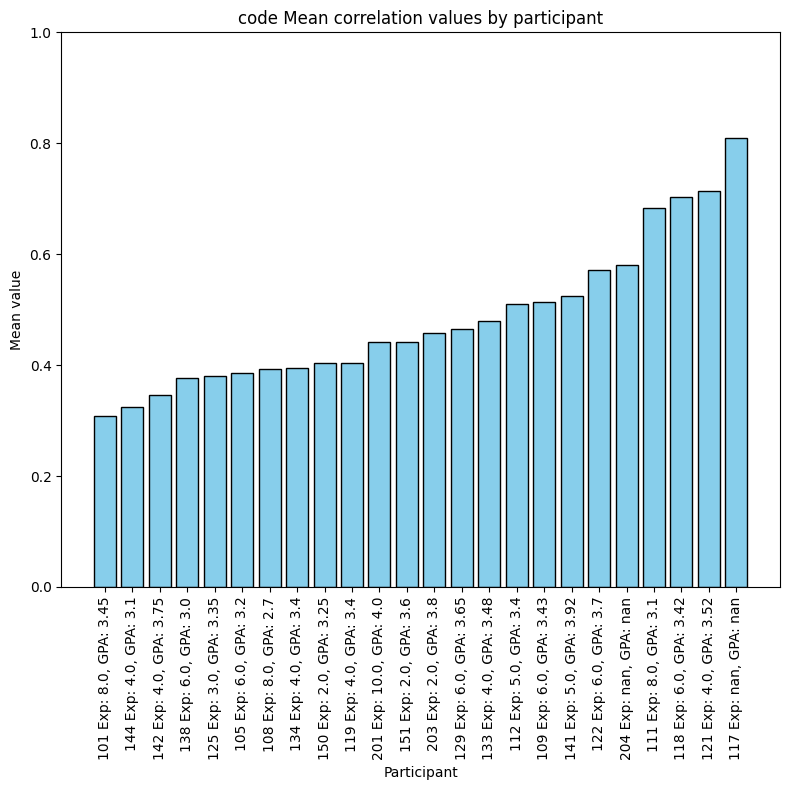

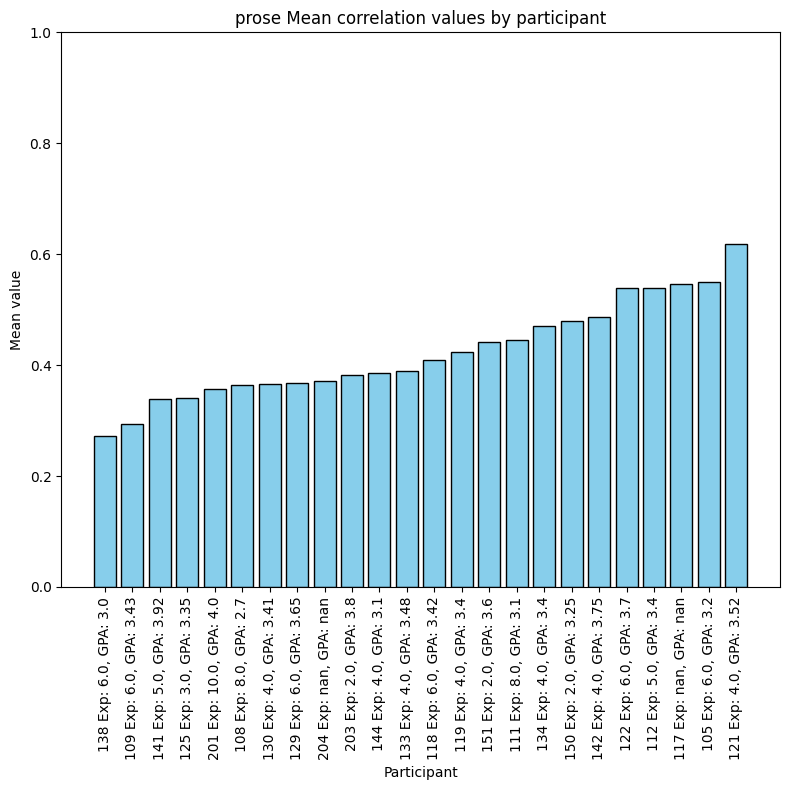

In [73]:
# by participant
def participant_index(id):
    return (np.where(demo_data['id'] == int(id)))[0][0]

demo_data = pd.read_csv("/home/zachkaras/fmri_model/master-survey-data.csv")
for task in ['code', 'prose']:
    
    sorted_means = dict(sorted(participant_means[task].items(), key=lambda x: x[1]))
    labels = list(sorted_means.keys())
    
    # Semesters experience and GPA
    labels = [f"{l} Exp: {demo_data.loc[participant_index(l), 'semesters_experience']}, GPA: {demo_data.loc[participant_index(l), 'GPA']}" for l in labels]

    means = sorted_means.values()
    # Plot
    plt.figure(figsize=(8,8))
    plt.bar(labels, means, color='skyblue', edgecolor='black')
    plt.ylabel("Mean value")
    plt.xlabel("Participant")
    plt.xticks(rotation=90)
    plt.ylim([0.0, 1])
    plt.title(f"{task} Mean correlation values by participant")
    plt.tight_layout()
    plt.show()

In [79]:
layer_means = {}
for (model, layer, task), df in records.groupby(['model', 'layer', 'task']):
    if task == 'prose':
        continue
    layer_mean = df['top_voxel_vals'].explode().mean()
    if model not in layer_means.keys():
        layer_means[model] = {layer : layer_mean}
    else:
        layer_means[model][layer] = layer_mean
    # print(model, layer, layer_mean)

In [84]:
for model,layers in layer_means.items():
    l = sorted(layers.keys(), key=lambda x: int(x.split('_')[1]))
    print(f"{model}_layers = {l}")

codegemma_2b_layers = ['layer_0', 'layer_4', 'layer_6', 'layer_10', 'layer_12', 'layer_14', 'layer_16', 'layer_18']
codegemma_7b_layers = ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_20', 'layer_24', 'layer_28']
deepseek_2b_layers = ['layer_0', 'layer_3', 'layer_6', 'layer_9', 'layer_12', 'layer_18', 'layer_21', 'layer_24']
deepseek_6b_layers = ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_24', 'layer_28', 'layer_32']
starcoder2_3b_layers = ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_20', 'layer_24', 'layer_28']
starcoder2_7b_layers = ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_20', 'layer_28', 'layer_32']


In [83]:
del layer_means['deepseek_2b']['layer_15']
del layer_means['codegemma_2b']['layer_2']
del layer_means['codegemma_2b']['layer_8']
del layer_means['deepseek_6b']['layer_20']
del layer_means['starcoder2_7b']['layer_24']

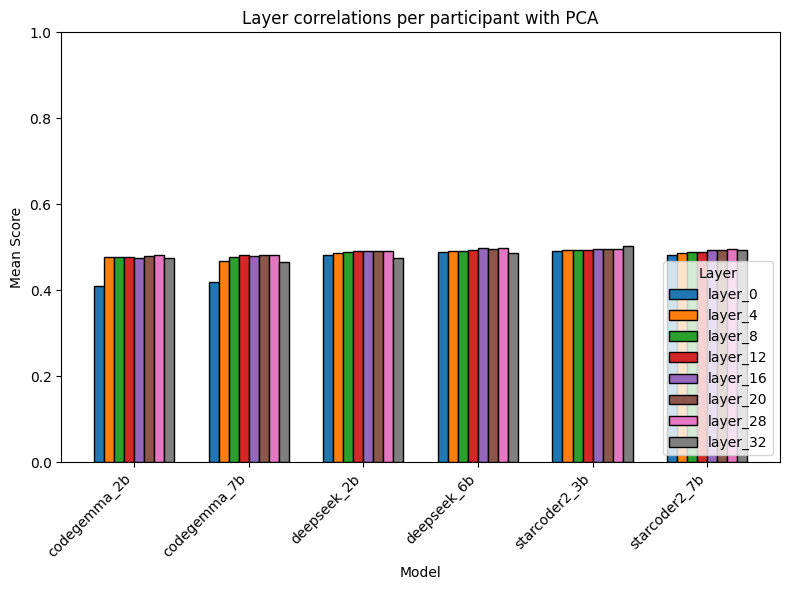

In [ ]:
models = list(layer_means.keys())
layers = list(next(iter(layer_means.values())).keys())  # assume all participants have same tasks

layers = sorted(
    next(iter(layer_means.values())).keys(),
    key=lambda x: int(x.split('_')[1])
)

# Compute means
means = {}
for model, layerScores in layer_means.items():
    layers = sorted(layerScores.keys(), key=lambda x: int(x.split('_')[1]))
    for layer in layers:
        scores = layer_means[model][layer]
        if model not in means.keys():
            means[model] = [scores]
        else:
            means[model].append(scores)
            
# Plot grouped bars
x = np.arange(len(models))  # positions for participants
width = 0.35 / len(layers) * 2     # adjust width depending on number of tasks

plt.figure(figsize=(8,6))
for i, layer in enumerate(layers):
    plt.bar(x + i*width, [np.mean(means[m][i]) for m in models],
            width, label=layer, edgecolor='black')

plt.xlabel("Model")
plt.ylim([0.0,0.7])
plt.ylabel("Mean Score")
plt.title("Layer correlations per participant with PCA")
plt.xticks(x + width*(len(layers)-1)/2, models, rotation=45, ha='right')
plt.legend(title="Layer", loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# participant_performance = defaultdict(list)

# # RQ2 - how do the model layers (early vs. late) relate to correlation? For each model, collect correlation values at each layer
# layer_means = nested_dict()

# # RQ3 - how do the different models relate to ridge regression performance? Collect correlation values for each model
# model_performance = defaultdict(list)

# # RQ4 - how do the tasks compare to one another? Collect correlation values for the two tasks
# task_performance = defaultdict(list)

# # task, model, delays, look_ahead

# for person, taskModelLayerStat in stat_collection.items():
#     for task, modelLayerStat in taskModelLayerStat.items():
#         if task == 'prose':
#             continue
#         for model,layerStat in modelLayerStat.items():
#             for layer,stat in layerStat.items():
#                 values = stat_collection[person][task][model][layer]
#                 # val = top_stds[person][task][model][layer]
#                 # val = corr_means[person][task][model][layer]
#                 # val = corr_stds[person][task][model][layer]
                
#                 participant_performance[person].extend(values)    
#                 model_performance[model].extend(values)
#                 task_performance[task].extend(values)
                
#                 if layer not in layer_means[model].keys():
#                     layer_means[model][layer] = values
#                 else:
#                     np.append(layer_means[model][layer], values)

In [ ]:
# # iterate through parcel_collection
# # participant, task, model name, delays, look ahead, layer

# # For a given participant, iterate through 

# # I'd like to plot all 8 layers for a given participant for a given model, for a given look ahead, for a given delay
# best_models = ['code-deepseek_6b-ndelays_4-look_ahead_by_10', 
#                'code-codegemma_7b-ndelays_4-look_ahead_by_10',
#                'code-codegemma_7b-ndelays_16-look_ahead_by_0', 
#                'prose-codegemma_7b-ndelays_10-look_ahead_by_5', 
#                'prose-deepseek_6b-ndelays_20-look_ahead_by_10']

# # Maybe a really good participant and a mediocre participant
# # Good - 121
# # Med. - 150
# # bad  - 144
# key_participants = ['144', '121', '150']
# for m in best_models:
#     # print(m)
#     parts = m.split('-')
#     task,model,delays,look_ahead = parts[0],parts[1],parts[2],parts[3]

#     for vip in key_participants:
#         # print(vip, task, model, delays, look_ahead)
#         # print(parcel_collection[vip][task][model][delays][look_ahead]['layer_0'])
#         top_parcels = parcel_collection[vip][task][model][delays][look_ahead]
        
#         # wrap this for loop in a plot to collect the different histograms
#         # plt.figure(figsize=(10,6))
#         # bins = 400

#         # for layer,vals in top_parcels.items():
#         #     # 
#         #     # plt.hist(vals, bins=bins, alpha=0.35, density=False)
#         #     plt.hist(vals, bins=bins, histtype='step', density=True)
#         # plt.legend(list(top_parcels.keys()))
#         # plt.show()
#     # break
            
    


In [ ]:
# """
# Overlapping Histogram — largest bar drawn first (behind), smaller bars in front.
# For each bin, each layer draws from 0 to its own count (no stacking).
# Accepts data as: {'label_1': [...], 'label_2': [...], ...}
# Values should be integers in range 1-400.
# """

# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# import matplotlib.transforms as mtransforms
# import seaborn as sns

# with open("schaefer_parcel_counts.pkl", 'rb') as f:
#     parcel_voxel_counts = pickle.load(f)

# # ── Configuration ────────────────────────────────────────────────────────────

# NUM_BINS = 200          # number of histogram bins
# VALUE_MIN = 1          # minimum possible value in data
# VALUE_MAX = 400        # maximum possible value in data
# FIGSIZE = (14, 6)      # figure dimensions (width, height)
# CHART_TITLE = "Group Distribution"

# # ─────────────────────────────────────────────────────────────────────────────


# def build_histogram(data: dict, num_bins: int, vmin: int, vmax: int) -> tuple:
#     """
#     Returns:
#         bin_edges  : array of length num_bins + 1
#         counts     : dict {label: array of length num_bins}
#     """
#     def calculate_voxel_proportion(num, idx):
#         total_vx_count = parcel_voxel_counts[idx+1]
#         proportion = num/total_vx_count
#         return proportion

#     bin_edges = np.linspace(vmin, vmax + 1, num_bins + 1)
#     counts = {}
#     for label, values in data.items():
#         hist, _ = np.histogram(values, bins=bin_edges)
#         ratios = [calculate_voxel_proportion(n, i) for i,n in enumerate(hist)]
#         counts[label] = ratios
#     return bin_edges, counts


# def plot_histogram(data: dict, num_bins: int = NUM_BINS,
#                    vmin: int = VALUE_MIN, vmax: int = VALUE_MAX,
#                    title: str = CHART_TITLE, figsize: tuple = FIGSIZE,
#                    region_boundaries=None):
#     """
#     region_boundaries: list of (start_pos, end_pos, region_number) tuples.
#       If provided, a horizontal line spans each region at two alternating
#       offsets below the x-axis, with the region number centered on the line.
#     """

#     bin_edges, counts = build_histogram(data, num_bins, vmin, vmax)
#     labels = list(counts.keys())
#     n_bins = num_bins
#     bin_width = bin_edges[1] - bin_edges[0]
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

#     sns.set_theme(style="ticks", context="talk")
#     palette = sns.color_palette("rainbow", len(labels))

#     sorted_labels = sorted(labels, key=lambda lbl: int(lbl.split("_")[-1]))
#     label_color = {lbl: palette[i] for i, lbl in enumerate(sorted_labels)}

#     fig, ax = plt.subplots(figsize=figsize)
#     ax.grid(axis="y", linewidth=0.8, linestyle="--", zorder=0)
#     ax.grid(axis="x", visible=False)

#     # ── Per-bin overlapping bars ──────────────────────────────────────────────
#     for b in range(n_bins):
#         sorted_by_count = sorted(labels, key=lambda lbl: counts[lbl][b], reverse=True)
#         sorted_by_count = sorted_by_count[:2]

#         for lbl in sorted_by_count:
#             val = counts[lbl][b]
#             if val == 0:
#                 continue
#             ax.bar(
#                 bin_centers[b],
#                 val,
#                 width=bin_width * 0.92,
#                 bottom=0,
#                 color=label_color[lbl],
#                 edgecolor="#2d2d4c",
#                 linewidth=0.4,
#                 zorder=2,
#             )

#     # ── Axes styling ──────────────────────────────────────────────────────────
#     ax.set_title(title, fontsize=16, fontweight="bold", pad=16, loc="left")
#     ax.set_xlabel("Cortical Region", color="#7070a0", fontsize=11, labelpad=45)
#     ax.set_ylabel("Proportion of Top Voxels in Schaefer Parcel", color="#7070a0", fontsize=11, labelpad=8)
#     ax.set_ylim([0.0, 1.0])
#     ax.tick_params(axis='y', colors="#5a5a8a", labelsize=9)
#     for spine in ax.spines.values():
#         spine.set_visible(False)

#     # ── X-axis: horizontal region lines and numbers ───────────────────────────
#     if region_boundaries is not None:
#         ax.set_xticks([])

#         # x in data coords, y in axes fraction (0 = plot bottom)
#         base_trans = ax.get_xaxis_transform()
#         # Two alternating y-offsets in points
#         line_offsets_pts = [-5, -25]
#         num_offsets_pts  = [-10, -31]

#         for i, (start, end, num) in enumerate(region_boundaries):
#             line_y = line_offsets_pts[i % 2]
#             num_y  = num_offsets_pts[i % 2]
#             mid    = (start + end + 1) / 2

#             # Horizontal line spanning the region
#             line_trans = mtransforms.offset_copy(base_trans, fig=fig, x=0, y=line_y, units='points')
#             ax.plot([start, end + 1], [0, 0], color="#5a5a8a", linewidth=1,
#                     transform=line_trans, clip_on=False)

#             # Region number centered on the line
#             ax.annotate(
#                 str(num),
#                 xy=(mid, 0), xycoords=('data', 'axes fraction'),
#                 xytext=(0, num_y), textcoords='offset points',
#                 ha='center', va='top', fontsize=10, color="#5a5a8a",
#                 clip_on=False,
#             )
#     else:
#         tick_step = max(1, n_bins // 8)
#         tick_positions = bin_edges[::tick_step]
#         ax.set_xticks(tick_positions)
#         ax.set_xticklabels([f"{int(v)}" for v in tick_positions], color="#5a5a8a")
#         ax.tick_params(axis='x', colors="#5a5a8a", labelsize=9)

#     # ── Legend (in sorted layer order) ───────────────────────────────────────
#     legend_patches = [
#         mpatches.Patch(color=label_color[lbl], label=lbl)
#         for lbl in sorted_labels
#     ]
#     ax.legend(
#         handles=legend_patches,
#         loc="best",
#         frameon=True,
#         framealpha=0.15,
#         edgecolor="#2a2a4a",
#         fontsize=9,
#         ncol=2,
#     )

#     plt.tight_layout()
#     plt.savefig("histogram_output.png", dpi=150, bbox_inches="tight",
#                 facecolor=fig.get_facecolor())
#     plt.show()


In [ ]:
# with open('/home/zachkaras/fmri_model/analysis/fir/schaefer_parcel_labels.pkl', 'rb') as f:
#     schaefer_parcel_labels = pickle.load(f)


# def compute_region_boundaries(hemi_order, parcel_labels):
#     """
#     Returns a list of (start_pos, end_pos, region_number) tuples,
#     one per unique HO cortical region, in the order they appear on the x-axis.
#     """
#     boundaries = []
#     current_region = None
#     start_pos = 0
#     region_num = 1
#     for i, p in enumerate(hemi_order):
#         region = parcel_labels[p]
#         if region != current_region:
#             if current_region is not None:
#                 boundaries.append((start_pos, i - 1, region_num))
#                 region_num += 1
#             current_region = region
#             start_pos = i
#     boundaries.append((start_pos, len(hemi_order) - 1, region_num))
#     return boundaries

# def plot_top_parcels(top_parcels, participant, model):
#     for hemi in ['left', 'right']:
#         hemi_order = list(schaefer_parcel_labels[hemi].keys())
#         pos_map = {p: i for i, p in enumerate(hemi_order)}

#         remapped = {
#             layer: [pos_map[v] for v in vals if v in pos_map]
#             for layer, vals in top_parcels.items()
#         }

#         region_boundaries = compute_region_boundaries(hemi_order, schaefer_parcel_labels[hemi])

#         # Print the region number → name mapping for reference
#         region_names = {}
#         current_region = None
#         region_num = 1
#         for p in hemi_order:
#             region = schaefer_parcel_labels[hemi][p]
#             if region != current_region:
#                 region_names[region_num] = region
#                 current_region = region
#                 region_num += 1
#         # print(f"\n{hemi} hemisphere region legend:")
#         # for num, name in region_names.items():
#         #     print(f"  {num}: {name}")

#         plot_histogram(remapped, num_bins=len(hemi_order), vmin=0, vmax=len(hemi_order) - 1,
#                     title=f"{participant}-{model}\n{hemi} hemisphere", region_boundaries=region_boundaries)


In [ ]:
# len(set(schaefer_parcel_labels['right'].values()))

46

In [86]:
# best_models = ['code-deepseek_6b-ndelays_4-look_ahead_by_10', 
#             #    'code-codegemma_7b-ndelays_4-look_ahead_by_10',
#             #    'code-codegemma_7b-ndelays_16-look_ahead_by_0', 
#                 'prose-deepseek_6b-ndelays_4-look_ahead_by_10' # not as good of performance, but keeps parameters consistent
#             #    'prose-codegemma_7b-ndelays_10-look_ahead_by_5', 
#             #    'prose-deepseek_6b-ndelays_20-look_ahead_by_10']

# # Maybe a really good participant and a mediocre participant
# # Good - 121
# # Med. - 150
# key_participants = ['144', '121', '150']
# for m in best_models:
#     # print(m)
#     parts = m.split('-')
#     task,model,delays,look_ahead = parts[0],parts[1],parts[2],parts[3]

#     for vip in key_participants:
#         top_parcels = parcel_collection[vip][task][model][delays][look_ahead]

#         if not top_parcels:
#             print(f"Skipping {vip} {m}: no data")
#             continue

#         plot_top_parcels(top_parcels, vip, m)

In [14]:
# R code for brains below these graphs
# install.packages("remotes")
# remotes::install_github("LCBC-UiO/ggsegHO")
# library(ggseg)

# ggseg(atlas = hoCort, mapping = aes(fill = region)) +
#   scale_fill_brain("hoCort", package = "ggsegHO") +
#   theme(legend.position = "bottom",
#         legend.text = element_text(size = 6)) +
#   guides(fill = guide_legend(ncol = 2))

In [ ]:
# from scipy.stats import hypergeom
# from statsmodels.stats.multitest import fdrcorrection

# def run_hypergeometric(top_parcel_list, parcel_voxel_counts, n_top=10_000):
#     """
#     Test which Schaefer parcels are significantly enriched among the top voxels.

#     Parameters
#     ----------
#     top_parcel_list   : list of ints — parcel label for each of the top n voxels
#     parcel_voxel_counts : dict {parcel_num: total_voxel_count}
#     n_top             : int — number of top voxels drawn (default 10k)

#     Returns
#     -------
#     results : list of dicts with keys:
#         parcel, observed, expected, p_raw, p_fdr, significant
#     """
#     N = sum(parcel_voxel_counts.values())  # total cortical voxels
#     n = n_top                               # top voxels drawn

#     # Count how many top voxels fell in each parcel
#     observed_counts = defaultdict(int)
#     for p in top_parcel_list:
#         observed_counts[p] += 1

#     parcels = sorted(parcel_voxel_counts.keys())

#     # Compute raw p-values via hypergeometric survival function
#     p_raw = []
#     for parcel in parcels:
#         K = parcel_voxel_counts[parcel]   # total voxels in this parcel
#         k = observed_counts.get(parcel, 0)  # observed in top n
#         # print(f"K: {K} | k: {k} | N: {N} | n: {n}")
#         p = hypergeom.sf(k - 1, N, K, n)   # P(X >= k)
#         p_raw.append(p)

#     # FDR correction across all parcels
#     rejected, p_fdr = fdrcorrection(p_raw, alpha=0.05)

#     results = []
#     for i, parcel in enumerate(parcels):
#         K = parcel_voxel_counts[parcel]
#         k = observed_counts.get(parcel, 0)
#         expected = (K / N) * n
#         results.append({
#             'parcel':      parcel,
#             'observed':    k,
#             'expected':    expected,
#             'fold_change': k / expected if expected > 0 else np.nan,
#             'p_raw':       p_raw[i],
#             'p_fdr':       p_fdr[i],
#             'significant': rejected[i],
#         })

#     return results


# # --- Example call (replace with your loop variables) ---
# # top_parcel_list = parcel_collection[participant][task][model][delays][look_ahead][layer]
# # results = run_hypergeometric(top_parcel_list, parcel_voxel_counts)
# # sig = [r for r in results if r['significant']]
# # print(f"{len(sig)} / 400 parcels significantly enriched")


# def filter_results(results):
#     total = 0
#     filtered_parcels = []
#     fold_changes = []
#     for r in results:
#         if r['significant']:
#             total += 1
#             filtered_parcels.append(r['parcel'])
#             fold_changes.append(r['fold_change'])
    
#     return {'num_sig_parcels' : total, 'enriched_parcels' : filtered_parcels}


In [16]:
# with open("schaefer_parcel_counts.pkl", 'rb') as f:
#     parcel_voxel_counts = pickle.load(f)

In [88]:
# participants = os.listdir(filepath)
# participant_result_dictionary = nested_dict()
# for m in best_models:
#     print(m)
#     parts = m.split('-')
#     task,model,delays,look_ahead = parts[0],parts[1],parts[2],parts[3]
    
#     for p in participants:
#         # print(p)
#         top_parcels = parcel_collection[p][task][model][delays][look_ahead]
        
#         if not top_parcels:
#             print(f"Skipping {vip} {m}: no data")
#             continue
        
#         # can iterate through different layers here
#         for layer,parcel_list in top_parcels.items():
#             # print(layer, p)
#             enrichment_results = run_hypergeometric(parcel_list, parcel_voxel_counts)
#             significant_results = filter_results(enrichment_results)
#             # print(enrichment_results)
#             participant_result_dictionary[m][layer][p] = significant_results
#             # participant_result_dictionary[m][layer][p] = enrichment_results
#     #         break
#     #     break
#     # break
#         # plot_top_parcels(top_parcels, vip, m)

In [87]:
# for m,l_p in participant_result_dictionary.items():
#     for l,p_results in l_p.items():
#         for p, results in p_results.items():
#             print(p, m, l, results)

In [ ]:
# import json

# participant_result_dictionary = json.loads(json.dumps(participant_result_dictionary))

# with open('results/participant_parcel_enrichment_results.pkl', 'wb') as f:
#     pickle.dump(participant_result_dictionary, f)

In [20]:
### TODO - check regions corresponding to Schaefer parcels